
sample = 1
Shannon Entropy  : -0.0
Min Entropy      : -0.0
Collision Entropy: -0.0

sample = 2
Shannon Entropy  : 1.0
Min Entropy      : 1.0
Collision Entropy: 1.0

sample = 5
Shannon Entropy  : 0.7219280948873623
Min Entropy      : 0.3219280948873623
Collision Entropy: 0.5563933485243849

sample = 10
Shannon Entropy  : 1.0
Min Entropy      : 1.0
Collision Entropy: 1.0

sample = 20
Shannon Entropy  : 0.934068055375491
Min Entropy      : 0.6214883767462701
Collision Entropy: 0.8756718649977983

sample = 50
Shannon Entropy  : 0.9426831892554922
Min Entropy      : 0.6438561897747247
Collision Entropy: 0.8911075983675909

sample = 100
Shannon Entropy  : 0.9974015885677396
Min Entropy      : 0.9159357352115255
Collision Entropy: 0.9948156241402767

sample = 200
Shannon Entropy  : 0.9999278640456615
Min Entropy      : 0.98564470702293
Collision Entropy: 0.9998557377089055

sample = 500
Shannon Entropy  : 0.9997114417528099
Min Entropy      : 0.9714308478032291
Collision Entropy: 0.999423037

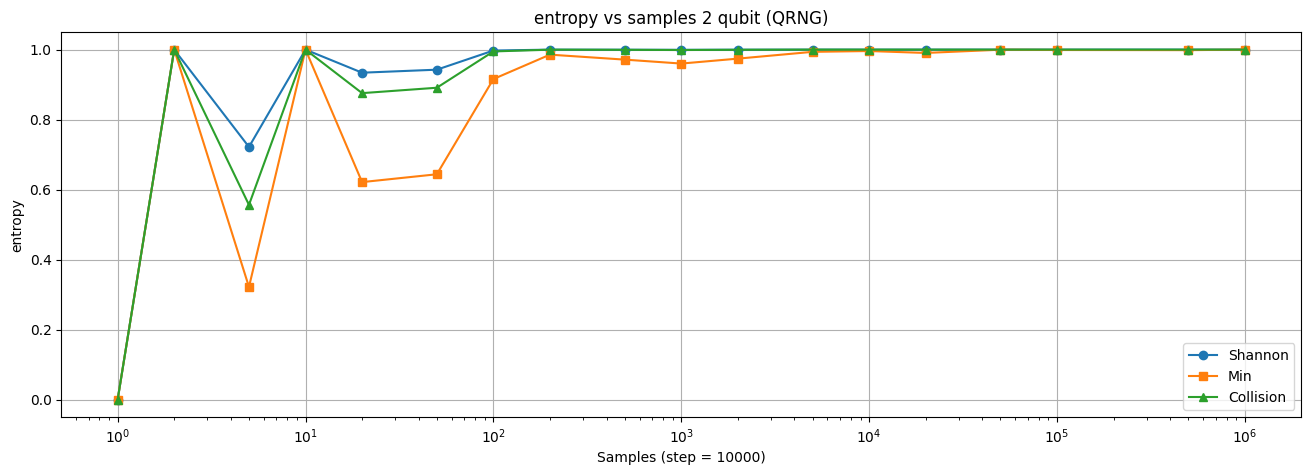

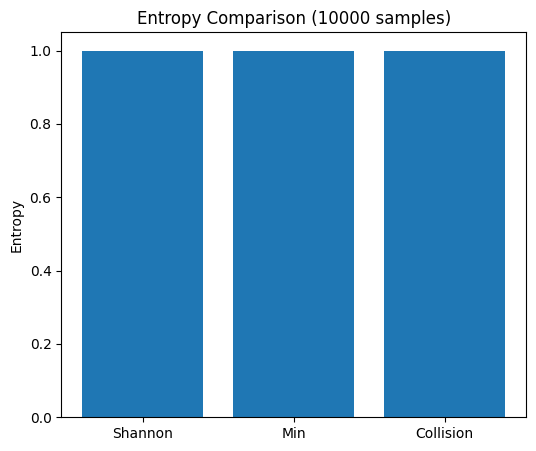

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import math
import matplotlib.pyplot as plt

# entropy 
def entropy_analysis(n):

    qc = QuantumCircuit(1)
    qc.h(0)
    qc.measure_all()

    sim = AerSimulator()
    compiled = transpile(qc, sim)

    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()

    total = sum(counts.values())

    # probabilities
    probs = [count / total for count in counts.values()]
    bit_sequence = []
    for outcome, count in counts.items():
        bit_sequence.extend([outcome] * count)

    import random
    random.shuffle(bit_sequence)

    bit_sequence = ''.join(bit_sequence)

    # Shannon Entropy
    shannon = -sum(p * math.log2(p) for p in probs)

    # Min Entropy
    min_ent = -math.log2(max(probs))

    # Collision Entropy
    collision = -math.log2(sum(p**2 for p in probs))

    return shannon, min_ent, collision, bit_sequence


#samples
samples = [1,2,5,10,20,50,100,200,500,1000,2000,5000,10000]

shannon_vals = []
min_vals = []
collision_vals = []

# all samples
for sample in samples:

    s, m, c, bits = entropy_analysis(sample)

    shannon_vals.append(s)
    min_vals.append(m)
    collision_vals.append(c)

    print(f"\nsample = {sample}")
    print("Shannon Entropy  :", s)
    print("Min Entropy      :", m)
    print("Collision Entropy:", c)


# graph btn samples vs entropy
plt.figure(figsize=(16,5))

plt.plot(samples, shannon_vals, marker='o', label='Shannon')
plt.plot(samples, min_vals, marker='s', label='Min')
plt.plot(samples, collision_vals, marker='^', label='Collision')
plt.xlabel("Samples (step = 10000)")
# plt.xlabel("samples")
plt.ylabel("entropy")
plt.title("entropy vs samples 2 qubit (QRNG)")
plt.xticks(samples)   # 👈 important line
plt.xscale('log')
plt.legend()
plt.grid()

plt.show()


# graph for comparism 
plt.figure(figsize=(6,5))

labels = ["Shannon", "Min", "Collision"]
values = [shannon_vals[-1], min_vals[-1], collision_vals[-1]]

plt.bar(labels, values)

plt.title("Entropy Comparison (10000 samples)")
plt.ylabel("Entropy")

plt.show()



Frequency test:- 

In [ ]:
print("Bits sample:", bits[:500])
print("Length:", len(bits))

Bits sample: 10101111010001111100100100111010001000011101100010111111110110111100101100011101101100101101000100010011010001110000100010110111011011011100010101011011100101101000100001100011000001110100000110011100111000011110000110001011001000101100100000100110011001101111100011111100001000001010011101000100011000111011000011110010110000001001100000101101100101010011100000100011101010110000001000001001011101110010011100110011110011110000011000111011111100110000000110011111000101100101100011000010001001010101
Length: 1000000


In [ ]:
percentage_ones = []

for sample in samples:

    _, _, _, bits = entropy_analysis(sample)

    ones = bits.count('1')
    total = len(bits)

    percent = (ones / total) * 100

    percentage_ones.append(percent)

    print(f"Sample={sample}")
    print(f"Percentage of 1s = {percent:.2f}%")

Sample=1
Percentage of 1s = 0.00%
Sample=2
Percentage of 1s = 100.00%
Sample=5
Percentage of 1s = 40.00%
Sample=10
Percentage of 1s = 30.00%
Sample=20
Percentage of 1s = 50.00%
Sample=50
Percentage of 1s = 46.00%
Sample=100
Percentage of 1s = 52.00%
Sample=200
Percentage of 1s = 45.50%
Sample=500
Percentage of 1s = 49.20%
Sample=1000
Percentage of 1s = 49.40%
Sample=2000
Percentage of 1s = 50.95%
Sample=5000
Percentage of 1s = 50.62%
Sample=10000
Percentage of 1s = 49.15%
Sample=20000
Percentage of 1s = 50.14%
Sample=50000
Percentage of 1s = 49.81%
Sample=100000
Percentage of 1s = 50.17%
Sample=500000
Percentage of 1s = 50.01%
Sample=1000000
Percentage of 1s = 50.07%


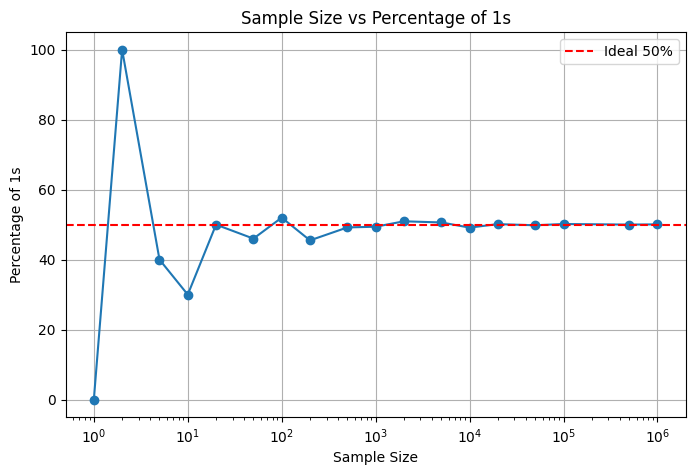

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(samples,percentage_ones,marker='o')

plt.axhline(y=50,color='red',linestyle='--',label='Ideal 50%')

plt.xlabel("Sample Size")
plt.ylabel("Percentage of 1s")
plt.title("Sample Size vs Percentage of 1s")
plt.xscale('log')
plt.legend()
plt.grid()

plt.show()

Run test:-

In [ ]:
from collections import Counter

bits = entropy_analysis(10000)[3]

run_lengths = []

current_run = 1

for i in range(1, len(bits)):

    if bits[i] == bits[i-1]:
        current_run += 1

    else:
        run_lengths.append(current_run)
        current_run = 1

run_lengths.append(current_run)

run_freq = Counter(run_lengths)

print("Run Length Frequency")
print(run_freq)

Run Length Frequency
Counter({1: 2517, 2: 1270, 3: 602, 4: 323, 5: 151, 6: 85, 7: 32, 8: 25, 9: 9, 10: 4, 11: 2, 13: 1})


In [ ]:
print("Bits sample:", bits[:1000])
print("Length:", len(bits))

Bits sample: 111000111101110010011110101101010111001100010001110100011101000011001110111101100110000001100001111100001001001111101110001001110100010010100110101100001011010000000100011010111110000111011110010101110111010100100011010101011010001100001101010011101111001010000001010010111000011101000100111000010100011000100000011010110010111111001010100011011111110001101001010010000001000010110001011111111100010111001001111001001101011101011100110100011111010010001001010011011001001110000110111111000111111111101011110110010011001000001000111110010011001100101011010011111011110111000011100111001100110111010100000000101110111001111011011111100001010101101111010010110111000110010101110011100110011001011001000111010000010000010010111111001011010001010111110000111010100100011101011111110100110110101100110000100010110011111110000110000011111011100101000110101011010011010100001110001010000111110001010100010001010101000011001101010111111100001000010010010100111000100111011100010100000000011000101

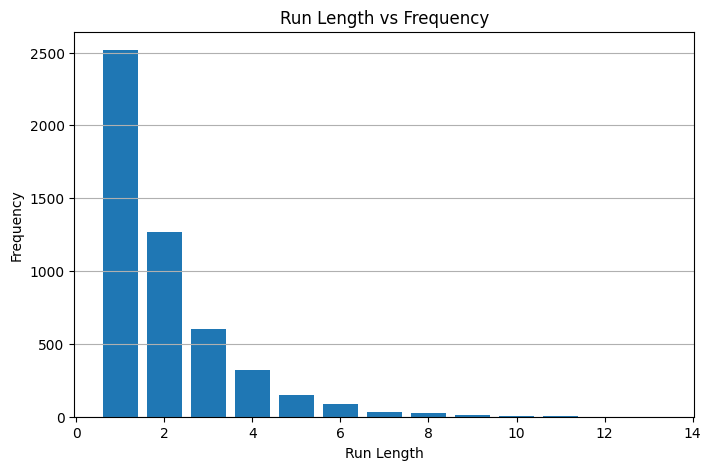

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(run_freq.keys(),run_freq.values())

plt.xlabel("Run Length")
plt.ylabel("Frequency")
plt.title("Run Length vs Frequency")


plt.grid(axis='y')

plt.show()

autocorelation test:-

In [ ]:
import numpy as np

data = np.array([int(b) for b in bits])

lags = range(1,21)

correlations = []

for lag in lags:

    corr = np.corrcoef(
        data[:-lag],
        data[lag:]
    )[0,1]

    correlations.append(corr)

    print(f"Lag {lag}: {corr:.4f}")

Lag 1: -0.0041
Lag 2: -0.0016
Lag 3: 0.0055
Lag 4: -0.0040
Lag 5: -0.0127
Lag 6: -0.0054
Lag 7: -0.0015
Lag 8: 0.0042
Lag 9: 0.0141
Lag 10: 0.0048
Lag 11: -0.0181
Lag 12: -0.0024
Lag 13: 0.0037
Lag 14: -0.0230
Lag 15: -0.0047
Lag 16: -0.0108
Lag 17: -0.0047
Lag 18: 0.0150
Lag 19: 0.0175
Lag 20: -0.0068


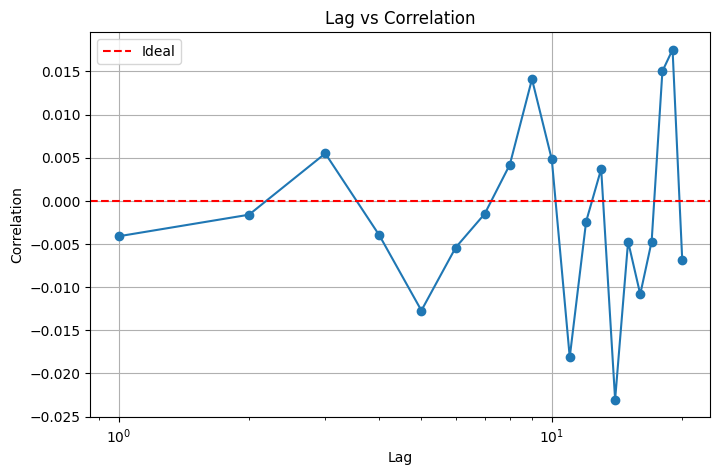

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(lags,
         correlations,
         marker='o')

plt.axhline(y=0,
            color='red',
            linestyle='--',
            label='Ideal')

plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("Lag vs Correlation")
plt.xscale('log')
plt.legend()
plt.grid()

plt.show()

In [ ]:
def shannon_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs)


def min_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -math.log2(max(probs))


def collision_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [c/total for c in counts.values()]
    return -math.log2(sum(p*p for p in probs))

Degration modlelling:- Bias

In [ ]:
def generate_bits(n):
    return [str(np.random.randint(0,2)) for _ in range(n)]

In [ ]:
import random
def apply_bias(bits, bias):
    # bias = probability of 1
    new_bits = []
    for _ in bits:
        if random.random() < bias:
            new_bits.append('1')
        else:
            new_bits.append('0')
    
    return new_bits


In [ ]:
bias_levels = np.linspace(0.5, 0.95, 10)

shannon_b, min_b, collision_b = [], [], []

for b in bias_levels:

    bits = apply_bias(generate_bits(10000), b)

    shannon_b.append(shannon_entropy(bits))
    min_b.append(min_entropy(bits))
    collision_b.append(collision_entropy(bits))

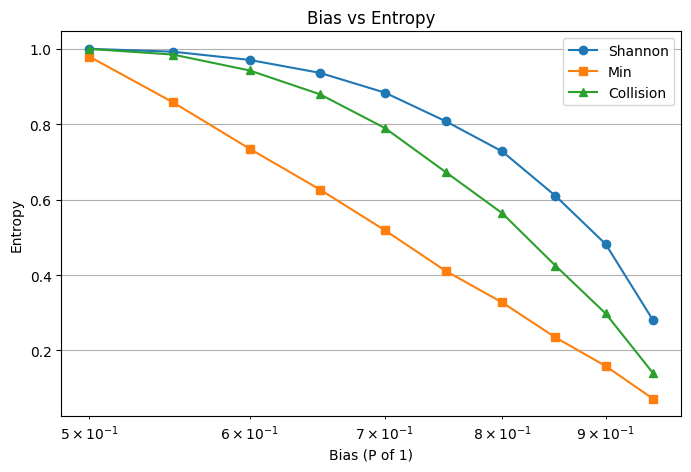

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(bias_levels, shannon_b, marker='o', label="Shannon")
plt.plot(bias_levels, min_b, marker='s', label="Min")
plt.plot(bias_levels, collision_b, marker='^', label="Collision")

plt.title("Bias vs Entropy")
plt.xlabel("Bias (P of 1)")
plt.ylabel("Entropy")
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

Noise simulation:

In [ ]:
def apply_noise(bits, noise):
    new_bits = []

    for b in bits:
        if random.random() < noise:
            new_bits.append('1' if b == '0' else '0')
        else:
            new_bits.append(b)

    return new_bits
noise_levels = np.linspace(0, 0.5, 10)

shannon_n, min_n, collision_n = [], [], []

for n in noise_levels:

    _, _, _, bits = entropy_analysis(10000)

    noisy = apply_noise(bits, n)

    shannon_n.append(shannon_entropy(noisy))
    min_n.append(min_entropy(noisy))
    collision_n.append(collision_entropy(noisy))

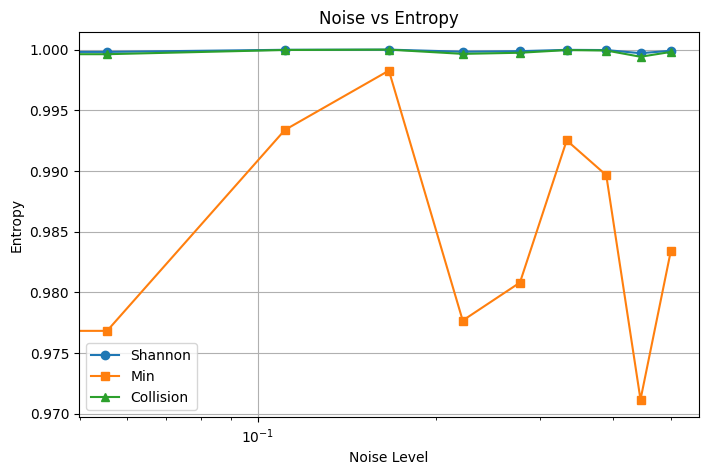

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(noise_levels, shannon_n, marker='o', label="Shannon")
plt.plot(noise_levels, min_n, marker='s', label="Min")
plt.plot(noise_levels, collision_n, marker='^', label="Collision")

plt.title("Noise vs Entropy")
plt.xlabel("Noise Level")
plt.ylabel("Entropy")
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

drift simulation: 

In [ ]:
time_steps = 50

shannon_d, min_d, collision_d = [], [], []

_, _, _, base_bits = entropy_analysis(10000)
for t in range(time_steps):

    bias = 0.5 + (t / time_steps) * 0.4

    drift_bits = apply_bias(base_bits, bias)

    shannon_d.append(shannon_entropy(drift_bits))
    min_d.append(min_entropy(drift_bits))
    collision_d.append(collision_entropy(drift_bits))

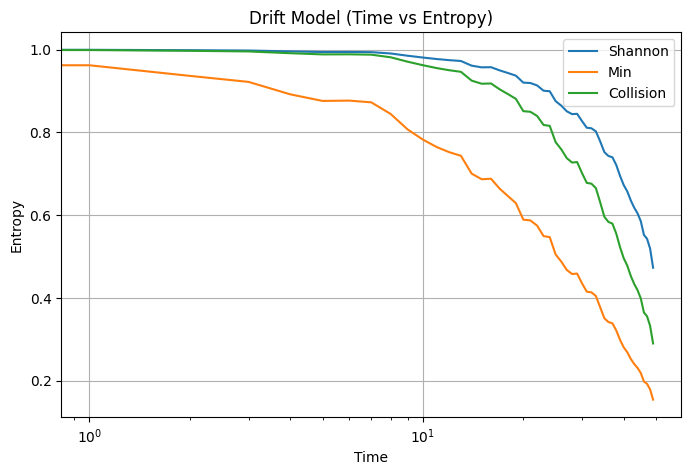

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(time_steps), shannon_d, label="Shannon")
plt.plot(range(time_steps), min_d, label="Min")
plt.plot(range(time_steps), collision_d, label="Collision")

plt.title("Drift Model (Time vs Entropy)")
plt.xlabel("Time")
plt.ylabel("Entropy")

plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

graph:- Bias vs Sample

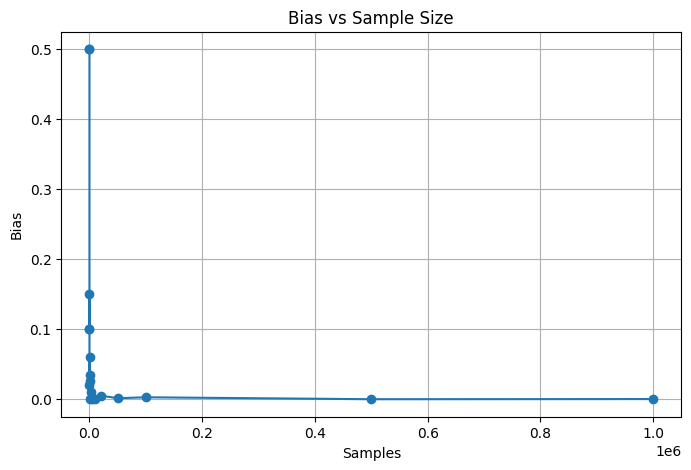

In [ ]:
bias_vals = []

for sample in samples:

    _, _, _, bits = entropy_analysis(sample)

    p1 = bits.count('1') / len(bits)

    bias = abs(p1 - 0.5)

    bias_vals.append(bias)

plt.figure(figsize=(8,5))

plt.plot(
    samples,
    bias_vals,
    marker='o'
)

plt.xlabel("Samples")
plt.ylabel("Bias")
plt.title("Bias vs Sample Size")

plt.grid()
plt.show()

In [ ]:
# ==========================================
# ONE-SCREEN QRNG REAL-TIME DASHBOARD
# ==========================================

import time
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import clear_output

# ---------- Helper Functions ----------

def clamp(x, low=0, high=100):
    return max(low, min(high, x))


def frequency_test(bits):
    n = len(bits)
    s = sum(1 if b == '1' else -1 for b in bits)
    sobs = abs(s) / math.sqrt(n)
    p_value = math.erfc(sobs / math.sqrt(2))
    return p_value


def runs_test(bits):
    n = len(bits)
    pi = bits.count('1') / n

    tau = 2 / math.sqrt(n)

    if abs(pi - 0.5) >= tau:
        return 0.0

    runs = 1

    for i in range(1, n):
        if bits[i] != bits[i - 1]:
            runs += 1

    numerator = abs(runs - 2 * n * pi * (1 - pi))
    denominator = 2 * math.sqrt(2 * n) * pi * (1 - pi)

    p_value = math.erfc(numerator / denominator)
    return p_value


def autocorrelation_value(bits, lag=1):
    data = np.array([int(b) for b in bits])

    if len(data) <= lag:
        return 0

    corr = np.corrcoef(data[:-lag], data[lag:])[0, 1]

    if np.isnan(corr):
        return 0

    return corr


def shannon_entropy_bitstream(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count / total for count in counts.values()]
    return -sum(p * math.log2(p) for p in probs)


def min_entropy_bitstream(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count / total for count in counts.values()]
    return -math.log2(max(probs))


def collision_entropy_bitstream(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count / total for count in counts.values()]
    return -math.log2(sum(p ** 2 for p in probs))


# ---------- Score Functions ----------

def score_high_good(value, worst, excellent):
    score = ((value - worst) / (excellent - worst)) * 100
    return clamp(score)


def score_low_good(value, excellent, worst):
    score = ((worst - value) / (worst - excellent)) * 100
    return clamp(score)


def score_p_value(p):
    score = ((p - 0.01) / (0.10 - 0.01)) * 100
    return clamp(score)


def category_from_score(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Good"
    elif score >= 60:
        return "Average"
    elif score >= 40:
        return "Warning"
    else:
        return "Worst"


# ---------- EHI Calculation ----------

def calculate_ehi(bits, previous_bias=None):
    n = len(bits)

    shannon = shannon_entropy_bitstream(bits)
    min_ent = min_entropy_bitstream(bits)
    collision = collision_entropy_bitstream(bits)

    freq_p = frequency_test(bits)
    runs_p = runs_test(bits)

    autocorr = abs(autocorrelation_value(bits, lag=1))

    p1 = bits.count('1') / n
    bias = abs(p1 - 0.5)

    noise = autocorr

    if previous_bias is None:
        drift = 0
    else:
        drift = abs(bias - previous_bias)

    s_shannon = score_high_good(shannon, 0.90, 0.99)
    s_min = score_high_good(min_ent, 0.85, 0.97)
    s_collision = score_high_good(collision, 0.88, 0.98)

    s_frequency = score_p_value(freq_p)
    s_runs = score_p_value(runs_p)
    s_autocorr = score_low_good(autocorr, 0.01, 0.10)

    s_bias = score_low_good(bias, 0.005, 0.05)
    s_noise = score_low_good(noise, 0.005, 0.05)
    s_drift = score_low_good(drift, 0.005, 0.05)

    ehi = (
        0.12 * s_shannon +
        0.20 * s_min +
        0.13 * s_collision +
        0.10 * s_frequency +
        0.10 * s_runs +
        0.10 * s_autocorr +
        0.10 * s_bias +
        0.07 * s_noise +
        0.08 * s_drift
    )

    status = category_from_score(ehi)

    results = {
        "Shannon": shannon,
        "Min": min_ent,
        "Collision": collision,
        "Frequency p": freq_p,
        "Runs p": runs_p,
        "Autocorrelation": autocorr,
        "Bias": bias,
        "Noise": noise,
        "Drift": drift,
        "EHI": ehi,
        "Status": status
    }

    return results, bias


# ---------- One Dashboard Function ----------

def one_screen_dashboard(iterations=20, sample_size=1000, delay=5):
    ehi_history = []
    time_history = []
    previous_bias = None

    for t in range(iterations):

        _, _, _, bits = entropy_analysis(sample_size)

        results, previous_bias = calculate_ehi(bits, previous_bias)

        ehi_history.append(results["EHI"])
        time_history.append(t * delay)

        clear_output(wait=True)

        fig = plt.figure(figsize=(16, 10))
        fig.suptitle("QRNG Real-Time Entropy Health Dashboard", fontsize=18, fontweight="bold")

        # ---------------- Panel 1: Current Health ----------------

        ax1 = plt.subplot(2, 3, 1)
        ax1.axis("off")

        ehi = results["EHI"]
        status = results["Status"]

        if status == "Excellent":
            color = "green"
        elif status == "Good":
            color = "limegreen"
        elif status == "Average":
            color = "orange"
        elif status == "Warning":
            color = "red"
        else:
            color = "darkred"

        ax1.text(0.5, 0.70, f"{ehi:.2f}%", ha="center", fontsize=38, fontweight="bold", color=color)
        ax1.text(0.5, 0.50, "Entropy Health Index", ha="center", fontsize=14)
        ax1.text(0.5, 0.30, f"Status: {status}", ha="center", fontsize=18, fontweight="bold", color=color)

        # ---------------- Panel 2: Entropy Values ----------------

        ax2 = plt.subplot(2, 3, 2)

        entropy_names = ["Shannon", "Min", "Collision"]
        entropy_values = [
            results["Shannon"],
            results["Min"],
            results["Collision"]
        ]

        ax2.bar(entropy_names, entropy_values, color=["royalblue", "seagreen", "purple"])
        ax2.set_ylim(0, 1.05)
        ax2.set_title("Entropy Values")
        ax2.set_ylabel("Entropy")

        for i, v in enumerate(entropy_values):
            ax2.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

        # ---------------- Panel 3: Statistical Tests ----------------

        ax3 = plt.subplot(2, 3, 3)

        test_names = ["Frequency", "Runs"]
        test_values = [
            results["Frequency p"],
            results["Runs p"]
        ]

        colors = ["green" if v >= 0.01 else "red" for v in test_values]

        ax3.bar(test_names, test_values, color=colors)
        ax3.axhline(y=0.01, color="red", linestyle="--", label="Fail Limit")
        ax3.set_ylim(0, 1)
        ax3.set_title("Statistical Test p-values")
        ax3.set_ylabel("p-value")
        ax3.legend()

        for i, v in enumerate(test_values):
            result_text = "Pass" if v >= 0.01 else "Fail"
            ax3.text(i, v + 0.03, f"{v:.3f}\n{result_text}", ha="center", fontweight="bold")

        # ---------------- Panel 4: Degradation Indicators ----------------

        ax4 = plt.subplot(2, 3, 4)

        degradation_names = ["Bias", "Noise", "Drift"]
        degradation_values = [
            results["Bias"] * 100,
            results["Noise"] * 100,
            results["Drift"] * 100
        ]

        ax4.bar(degradation_names, degradation_values, color=["tomato", "gold", "darkorange"])
        ax4.set_title("Degradation Indicators")
        ax4.set_ylabel("Percentage / Value (%)")

        for i, v in enumerate(degradation_values):
            ax4.text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")

        # ---------------- Panel 5: Live EHI Graph ----------------

        ax5 = plt.subplot(2, 3, 5)

        ax5.plot(time_history, ehi_history, marker="o", color="green", linewidth=2)
        ax5.axhline(y=90, color="blue", linestyle="--", label="Excellent")
        ax5.axhline(y=75, color="green", linestyle="--", label="Good")
        ax5.axhline(y=60, color="orange", linestyle="--", label="Average")
        ax5.axhline(y=40, color="red", linestyle="--", label="Warning")

        ax5.set_title("Live EHI Graph")
        ax5.set_xlabel("Time (seconds)")
        ax5.set_ylabel("EHI (%)")
        ax5.set_ylim(0, 105)
        ax5.grid()
        ax5.legend(fontsize=8)

        # ---------------- Panel 6: Autocorrelation ----------------

        ax6 = plt.subplot(2, 3, 6)

        lags = range(1, 11)
        corr_values = []

        for lag in lags:
            corr_values.append(autocorrelation_value(bits, lag))

        ax6.plot(list(lags), corr_values, marker="o", color="crimson")
        ax6.axhline(y=0, color="black", linestyle="--")
        ax6.axhline(y=0.05, color="red", linestyle="--", alpha=0.5)
        ax6.axhline(y=-0.05, color="red", linestyle="--", alpha=0.5)

        ax6.set_title("Autocorrelation Test")
        ax6.set_xlabel("Lag")
        ax6.set_ylabel("Correlation")
        ax6.grid()

        plt.tight_layout()
        plt.show()

        time.sleep(delay)
        
print("Bits sample:", bits[:1000])
print("Length:", len(bits))

Bits sample: 011101000001111010011111001011000011110010000000000110000001000111110011101100110100111100000011101101001110110001011101001001010001011110001001011011110011010010000110001000011001001001010011001101010100010000001011100010100010001010011001100010100010111101010000110100111110000110101000001011111110100000101101110110000001001000000001100000100001110010011101000110101010110011001110001011011110001011000101101011100011111100001000111100010011101011010110010100001101110111110001000100111001010011010111110101000011011111100100010100101011010001001110011111001101110011000110100100000101000011111101100001111101011111111100010010010110100101001010101011001101110101100011010101100011100110111011100001101001011010010001111011010111001110111011110010000001011110100111111101001111010010011001111010010000001101110001010011010111001001110101000101010001000001100011100100111110011011011110101111011111101110000111001001010110100110011111101100101100111111100111111010111100000110010111110

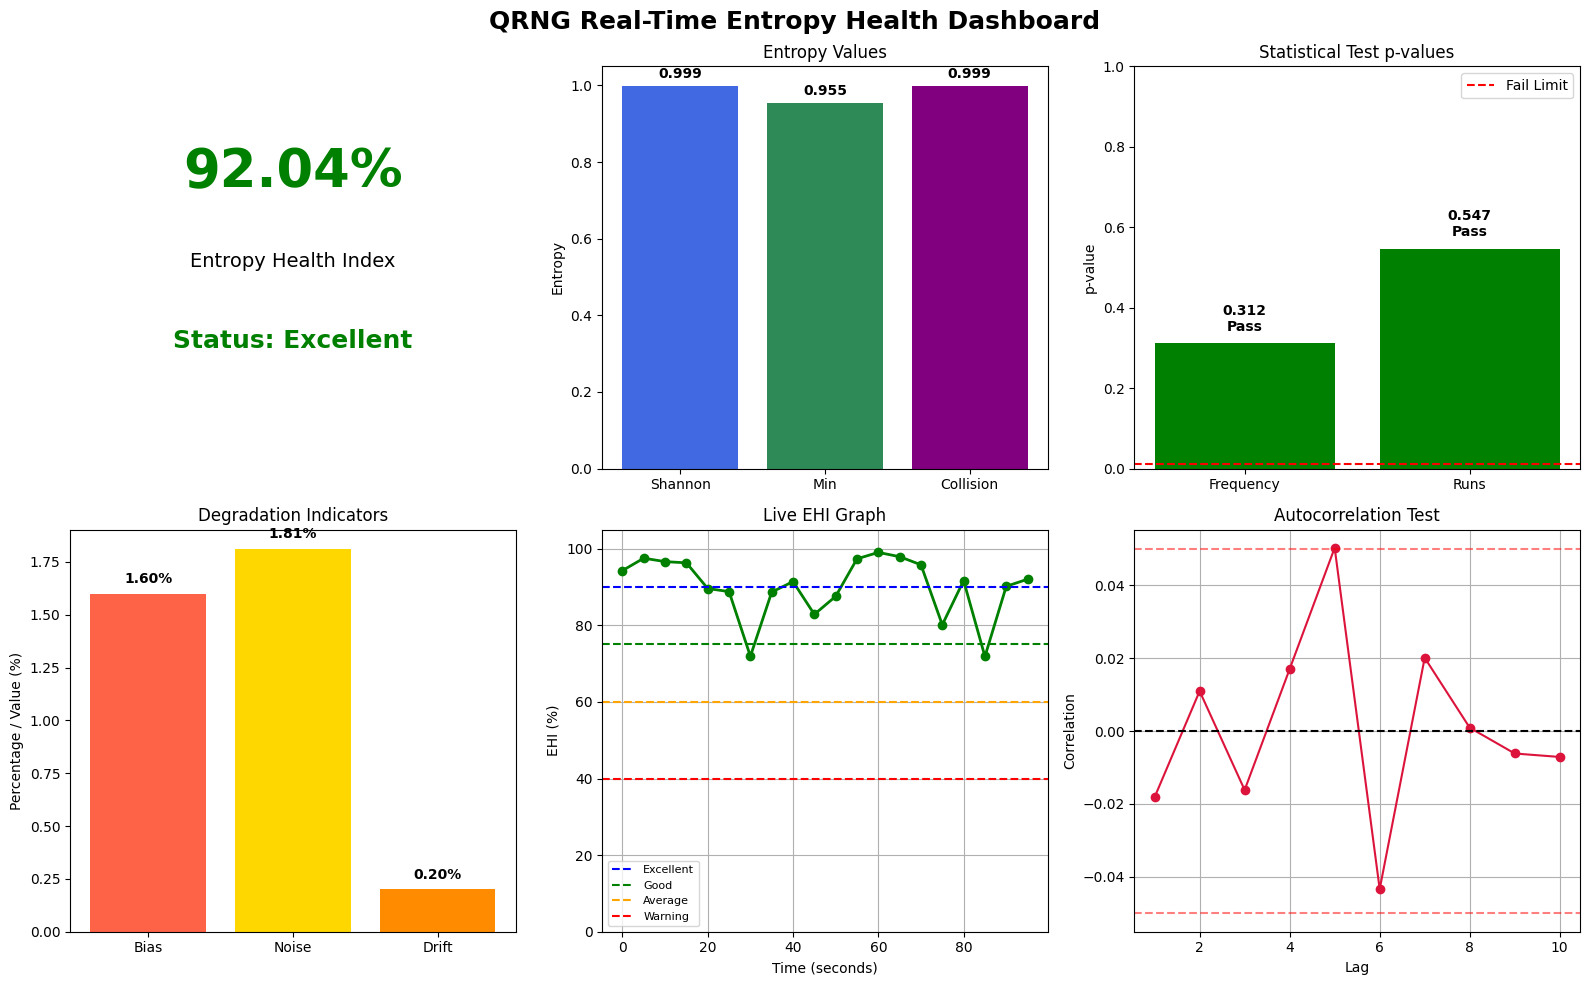

In [ ]:
one_screen_dashboard(iterations=20, sample_size=1000, delay=5)

In [ ]:
# ================================
# STEP 5: ENTROPY HEALTH INDEX
# ================================

import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import clear_output, display

# ---------- Basic helper ----------

def clamp(x, low=0, high=100):
    return max(low, min(high, x))


# ---------- Statistical Tests ----------

def frequency_test(bits):
    """
    NIST-style Frequency Monobit Test.
    Returns p-value.
    """
    n = len(bits)
    s = sum(1 if b == '1' else -1 for b in bits)
    sobs = abs(s) / math.sqrt(n)
    p_value = math.erfc(sobs / math.sqrt(2))
    return p_value


def runs_test(bits):
    """
    NIST-style Runs Test.
    Returns p-value.
    """
    n = len(bits)
    pi = bits.count('1') / n

    tau = 2 / math.sqrt(n)

    if abs(pi - 0.5) >= tau:
        return 0.0

    runs = 1
    for i in range(1, n):
        if bits[i] != bits[i - 1]:
            runs += 1

    numerator = abs(runs - 2 * n * pi * (1 - pi))
    denominator = 2 * math.sqrt(2 * n) * pi * (1 - pi)

    p_value = math.erfc(numerator / denominator)
    return p_value


def autocorrelation_value(bits, lag=1):
    """
    Autocorrelation at selected lag.
    Ideal value is close to 0.
    """
    data = np.array([int(b) for b in bits])

    if len(data) <= lag:
        return 0

    corr = np.corrcoef(data[:-lag], data[lag:])[0, 1]

    if np.isnan(corr):
        return 0

    return corr


# ---------- Entropy Functions for Bitstream ----------

def shannon_entropy_bitstream(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count / total for count in counts.values()]
    return -sum(p * math.log2(p) for p in probs)


def min_entropy_bitstream(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count / total for count in counts.values()]
    return -math.log2(max(probs))


def collision_entropy_bitstream(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count / total for count in counts.values()]
    return -math.log2(sum(p ** 2 for p in probs))


# ---------- Score Conversion ----------

def score_high_good(value, worst, excellent):
    """
    For metrics where high value is better.
    Example: entropy.
    """
    score = ((value - worst) / (excellent - worst)) * 100
    return clamp(score)


def score_low_good(value, excellent, worst):
    """
    For metrics where low value is better.
    Example: bias, noise, drift, autocorrelation.
    """
    score = ((worst - value) / (worst - excellent)) * 100
    return clamp(score)


def score_p_value(p):
    """
    For statistical test p-values.
    p < 0.01 means fail.
    p >= 0.10 means excellent.
    """
    score = ((p - 0.01) / (0.10 - 0.01)) * 100
    return clamp(score)


# ---------- Category Function ----------

def category_from_score(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Good"
    elif score >= 60:
        return "Average"
    elif score >= 40:
        return "Warning"
    else:
        return "Worst"


# ---------- EHI Calculation ----------

def calculate_ehi(bits, previous_bias=None):
    n = len(bits)

    shannon = shannon_entropy_bitstream(bits)
    min_ent = min_entropy_bitstream(bits)
    collision = collision_entropy_bitstream(bits)

    freq_p = frequency_test(bits)
    runs_p = runs_test(bits)

    autocorr = abs(autocorrelation_value(bits, lag=1))

    p1 = bits.count('1') / n
    bias = abs(p1 - 0.5)

    # In a real device, noise comes from hardware error estimate.
    # Here we use autocorrelation as noise indicator.
    noise = autocorr

    # Drift means change in bias compared to previous window.
    if previous_bias is None:
        drift = 0
    else:
        drift = abs(bias - previous_bias)

    # Individual scores
    s_shannon = score_high_good(shannon, 0.90, 0.99)
    s_min = score_high_good(min_ent, 0.85, 0.97)
    s_collision = score_high_good(collision, 0.88, 0.98)

    s_frequency = score_p_value(freq_p)
    s_runs = score_p_value(runs_p)
    s_autocorr = score_low_good(autocorr, 0.01, 0.10)

    s_bias = score_low_good(bias, 0.005, 0.05)
    s_noise = score_low_good(noise, 0.005, 0.05)
    s_drift = score_low_good(drift, 0.005, 0.05)

    ehi = (
        0.12 * s_shannon +
        0.20 * s_min +
        0.13 * s_collision +
        0.10 * s_frequency +
        0.10 * s_runs +
        0.10 * s_autocorr +
        0.10 * s_bias +
        0.07 * s_noise +
        0.08 * s_drift
    )

    status = category_from_score(ehi)

    results = {
        "Shannon Entropy": shannon,
        "Min Entropy": min_ent,
        "Collision Entropy": collision,
        "Frequency p-value": freq_p,
        "Runs p-value": runs_p,
        "Autocorrelation": autocorr,
        "Bias": bias,
        "Noise": noise,
        "Drift": drift,
        "EHI": ehi,
        "Status": status
    }

    return results, bias

In [ ]:
# ================================
# REAL-TIME QRNG DASHBOARD
# ================================

def realtime_dashboard(iterations=20, sample_size=1000, delay=5):
    ehi_history = []
    time_history = []
    previous_bias = None

    for t in range(iterations):

        # Generate QRNG bits using your existing entropy_analysis function
        _, _, _, bits = entropy_analysis(sample_size)

        results, previous_bias = calculate_ehi(bits, previous_bias)

        ehi_history.append(results["EHI"])
        time_history.append(t * delay)

        clear_output(wait=True)

        print("======================================")
        print("      QRNG REAL-TIME HEALTH DASHBOARD")
        print("======================================")

        print("\nPanel 1: Current Health")
        print(f"EHI    : {results['EHI']:.2f}%")
        print(f"Status : {results['Status']}")

        print("\nPanel 2: Entropy Values")
        print(f"Shannon Entropy   : {results['Shannon Entropy']:.4f}")
        print(f"Min Entropy       : {results['Min Entropy']:.4f}")
        print(f"Collision Entropy : {results['Collision Entropy']:.4f}")

        print("\nPanel 3: Statistical Tests")
        print(f"Frequency Test p-value : {results['Frequency p-value']:.4f}")
        print(f"Runs Test p-value      : {results['Runs p-value']:.4f}")
        print(f"Autocorrelation        : {results['Autocorrelation']:.4f}")

        print("\nPanel 4: Degradation Indicators")
        print(f"Bias  : {results['Bias'] * 100:.2f}%")
        print(f"Noise : {results['Noise'] * 100:.2f}%")
        print(f"Drift : {results['Drift'] * 100:.2f}%")

        print("\nPanel 5: Live EHI Graph")

        plt.figure(figsize=(9, 5))
        plt.plot(time_history, ehi_history, marker='o', color='green', label='EHI')

        plt.axhline(y=90, color='blue', linestyle='--', label='Excellent')
        plt.axhline(y=75, color='green', linestyle='--', label='Good')
        plt.axhline(y=60, color='orange', linestyle='--', label='Average')
        plt.axhline(y=40, color='red', linestyle='--', label='Warning')

        plt.xlabel("Time (seconds)")
        plt.ylabel("Entropy Health Index (%)")
        plt.title("Real-Time QRNG Entropy Health Index")
        plt.ylim(0, 105)
        plt.grid()
        plt.legend()
        plt.show()

        time.sleep(delay)

      QRNG REAL-TIME HEALTH DASHBOARD

Panel 1: Current Health
EHI    : 83.86%
Status : Good

Panel 2: Entropy Values
Shannon Entropy   : 1.0000
Min Entropy       : 0.9914
Collision Entropy : 0.9999

Panel 3: Statistical Tests
Frequency Test p-value : 0.8495
Runs Test p-value      : 0.0668
Autocorrelation        : 0.0590

Panel 4: Degradation Indicators
Bias  : 0.30%
Noise : 5.90%
Drift : 0.40%

Panel 5: Live EHI Graph


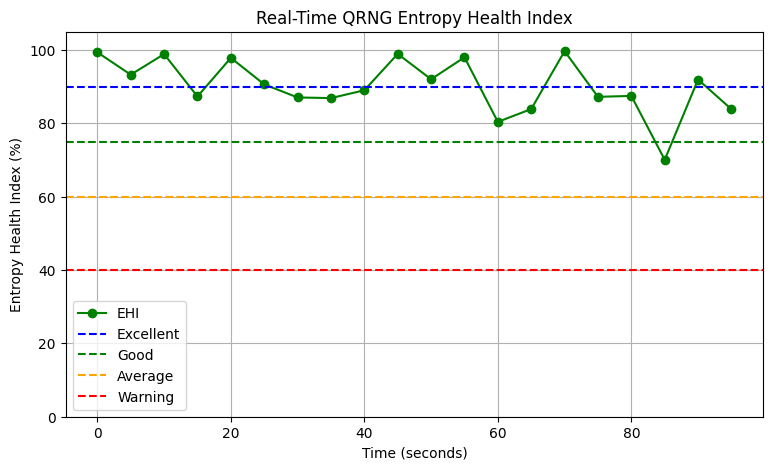

In [ ]:
realtime_dashboard(iterations=20, sample_size=1000, delay=5)

In [ ]:
def calculate_bias(bits):

    p1 = bits.count('1') / len(bits)

    return abs(p1 - 0.5)


def calculate_noise(bits):

    transitions = 0

    for i in range(1, len(bits)):

        if bits[i] != bits[i-1]:
            transitions += 1

    return abs((transitions/len(bits)) - 0.5)


def calculate_drift(bits):

    half = len(bits)//2

    first = bits[:half]
    second = bits[half:]

    p1 = first.count('1')/len(first)
    p2 = second.count('1')/len(second)

    return abs(p1-p2)

In [ ]:
def entropy_health_index(bits, correlations):

    shannon = shannon_entropy(bits)
    minent = min_entropy(bits)
    collision = collision_entropy(bits)

    bias = calculate_bias(bits)

    noise = calculate_noise(bits)

    drift = calculate_drift(bits)

    auto = np.mean(np.abs(correlations))

    S_shannon = (shannon/2)*100
    S_min = (minent/2)*100
    S_collision = (collision/2)*100

    S_auto = (1-auto)*100

    S_bias = (1-bias)*100
    S_noise = (1-noise)*100
    S_drift = (1-drift)*100

    EHI = (
        0.20*S_shannon +
        0.20*S_min +
        0.10*S_collision +
        0.10*S_auto +
        0.14*S_bias +
        0.13*S_noise +
        0.13*S_drift
    )

    return EHI

In [ ]:
def health_status(ehi):

    if ehi >= 90:
        return "EXCELLENT"

    elif ehi >= 75:
        return "GOOD"

    elif ehi >= 60:
        return "AVERAGE"

    elif ehi >= 40:
        return "WARNING"

    else:
        return "WORST"

In [ ]:
_, _, _, bits = entropy_analysis(100000)

data = np.array([int(b) for b in bits])

lags = range(1,21)

correlations = []

for lag in lags:

    corr = np.corrcoef(
        data[:-lag],
        data[lag:]
    )[0,1]

    correlations.append(corr)

ehi = entropy_health_index(
    bits,
    correlations
)

print("="*50)
print("QRNG HEALTH MONITOR")
print("="*50)

print(f"\nEHI = {ehi:.2f}%")

print(
    "Status =",
    health_status(ehi)
)

print("\nEntropy Values")

print(
    f"Shannon Entropy = {shannon_entropy(bits):.4f}"
)

print(
    f"Min Entropy = {min_entropy(bits):.4f}"
)

print(
    f"Collision Entropy = {collision_entropy(bits):.4f}"
)

print("\nDegradation Indicators")

print(
    f"Bias = {calculate_bias(bits)*100:.2f}%"
)

print(
    f"Noise = {calculate_noise(bits)*100:.2f}%"
)

print(
    f"Drift = {calculate_drift(bits)*100:.2f}%"
)

QRNG HEALTH MONITOR

EHI = 74.89%
Status = AVERAGE

Entropy Values
Shannon Entropy = 1.0000
Min Entropy = 0.9999
Collision Entropy = 1.0000

Degradation Indicators
Bias = 0.00%
Noise = 0.00%
Drift = 0.66%


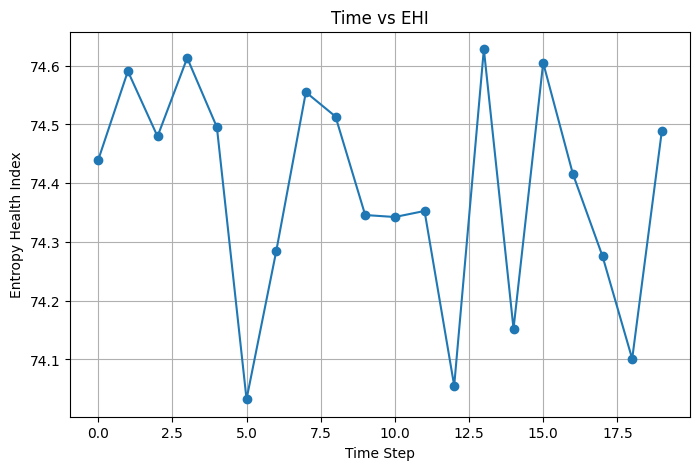

In [ ]:
ehi_history = []

for i in range(20):

    _, _, _, bits = entropy_analysis(5000)

    data = np.array([int(b) for b in bits])

    correlations = []

    for lag in range(1,21):

        corr = np.corrcoef(
            data[:-lag],
            data[lag:]
        )[0,1]

        correlations.append(corr)

    ehi = entropy_health_index(
        bits,
        correlations
    )

    ehi_history.append(ehi)

plt.figure(figsize=(8,5))

plt.plot(
    range(len(ehi_history)),
    ehi_history,
    marker='o'
)

plt.title("Time vs EHI")

plt.xlabel("Time Step")

plt.ylabel("Entropy Health Index")

plt.grid()

plt.show()

In [ ]:
def von_neumann_extractor(bits):

    output = []

    for i in range(0, len(bits)-1, 2):

        pair = bits[i:i+2]

        if pair == "01":
            output.append("0")

        elif pair == "10":
            output.append("1")

    return ''.join(output)

In [ ]:
_, _, _, bits = entropy_analysis(100000)

vn_bits = von_neumann_extractor(bits)

print("Original Length :", len(bits))
print("Corrected Length:", len(vn_bits))

print("\nBefore Correction")

print("Shannon   :", shannon_entropy(bits))
print("Min       :", min_entropy(bits))
print("Collision :", collision_entropy(bits))

print("\nAfter Von Neumann")

print("Shannon   :", shannon_entropy(vn_bits))
print("Min       :", min_entropy(vn_bits))
print("Collision :", collision_entropy(vn_bits))

Original Length : 100000
Corrected Length: 24925

Before Correction
Shannon   : 0.9999999166122251
Min       : 0.9995095670549747
Collision : 0.9999998332244628

After Von Neumann
Shannon   : 0.9999988841708342
Min       : 0.9982067900793685
Collision : 0.9999977683439697


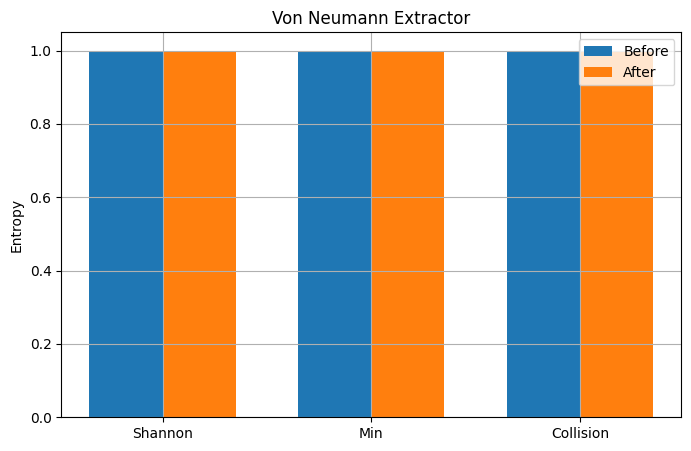

In [ ]:
before = [
    shannon_entropy(bits),
    min_entropy(bits),
    collision_entropy(bits)
]

after = [
    shannon_entropy(vn_bits),
    min_entropy(vn_bits),
    collision_entropy(vn_bits)
]

labels = [
    "Shannon",
    "Min",
    "Collision"
]

x = np.arange(len(labels))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x-width/2,
    before,
    width,
    label="Before"
)

plt.bar(
    x+width/2,
    after,
    width,
    label="After"
)

plt.xticks(x, labels)

plt.title("Von Neumann Extractor")

plt.ylabel("Entropy")

plt.legend()

plt.grid()

plt.show()

In [ ]:
import hashlib

def hash_extractor(bits):

    byte_data = int(bits,2).to_bytes(
        (len(bits)+7)//8,
        byteorder='big'
    )

    digest = hashlib.sha256(
        byte_data
    ).hexdigest()

    return bin(
        int(digest,16)
    )[2:].zfill(256)

In [ ]:
hash_bits = hash_extractor(bits)

print("Original Length :", len(bits))
print("Hash Length     :", len(hash_bits))

print("\nAfter Hash Extractor")

print("Shannon   :", shannon_entropy(hash_bits))
print("Min       :", min_entropy(hash_bits))
print("Collision :", collision_entropy(hash_bits))

Original Length : 100000
Hash Length     : 256

After Hash Extractor
Shannon   : 0.9996037156868482
Min       : 0.9665769984625497
Collision : 0.999207721530688


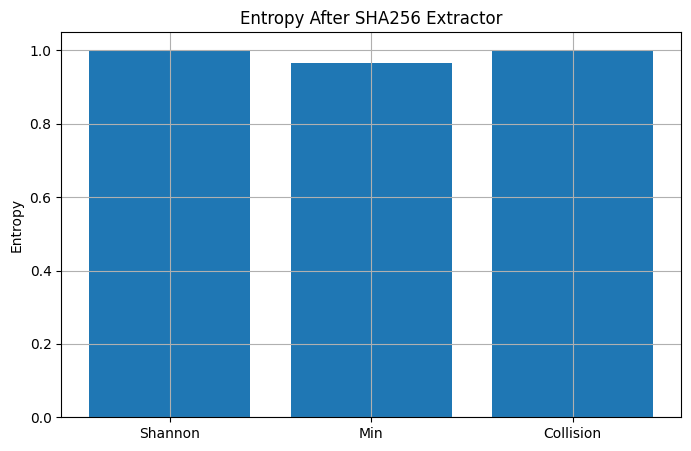

In [ ]:
hash_values = [

    shannon_entropy(hash_bits),

    min_entropy(hash_bits),

    collision_entropy(hash_bits)

]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    hash_values
)

plt.title(
    "Entropy After SHA256 Extractor"
)

plt.ylabel("Entropy")

plt.grid()

plt.show()

In [ ]:
def calculate_bias(bits):

    p1 = bits.count('1')/len(bits)

    return abs(p1-0.5)

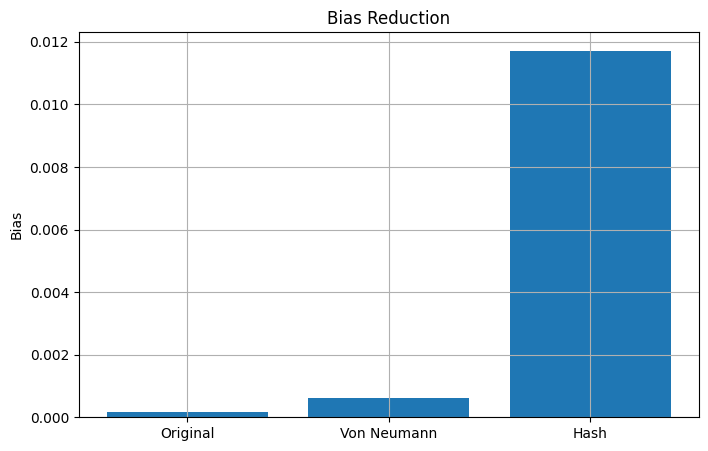

In [ ]:
bias_before = calculate_bias(bits)

bias_vn = calculate_bias(vn_bits)

bias_hash = calculate_bias(hash_bits)

plt.figure(figsize=(8,5))

plt.bar(
    ["Original","Von Neumann","Hash"],
    [bias_before,bias_vn,bias_hash]
)

plt.title("Bias Reduction")

plt.ylabel("Bias")

plt.grid()

plt.show()

In [ ]:
print("------------------------------------------------")
print("METHOD\t\tSHANNON\tMIN\tCOLLISION")
print("------------------------------------------------")

print(
    f"Original\t"
    f"{shannon_entropy(bits):.4f}\t"
    f"{min_entropy(bits):.4f}\t"
    f"{collision_entropy(bits):.4f}"
)

print(
    f"VonNeumann\t"
    f"{shannon_entropy(vn_bits):.4f}\t"
    f"{min_entropy(vn_bits):.4f}\t"
    f"{collision_entropy(vn_bits):.4f}"
)

print(
    f"SHA256\t\t"
    f"{shannon_entropy(hash_bits):.4f}\t"
    f"{min_entropy(hash_bits):.4f}\t"
    f"{collision_entropy(hash_bits):.4f}"
)

------------------------------------------------
METHOD		SHANNON	MIN	COLLISION
------------------------------------------------
Original	1.0000	0.9995	1.0000
VonNeumann	1.0000	0.9982	1.0000
SHA256		0.9996	0.9666	0.9992


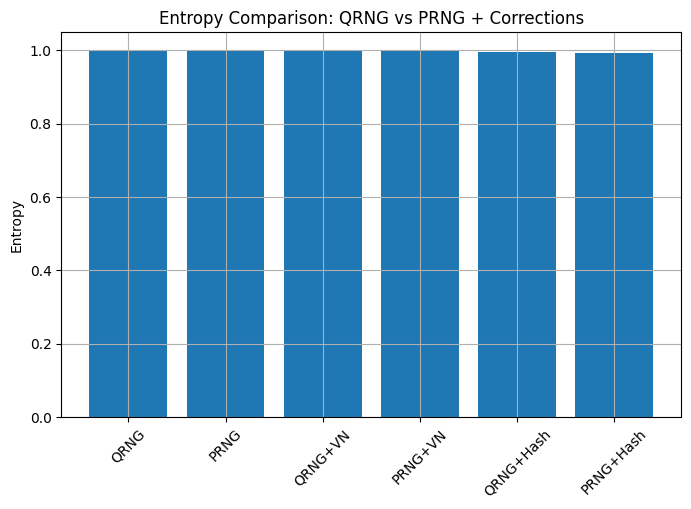

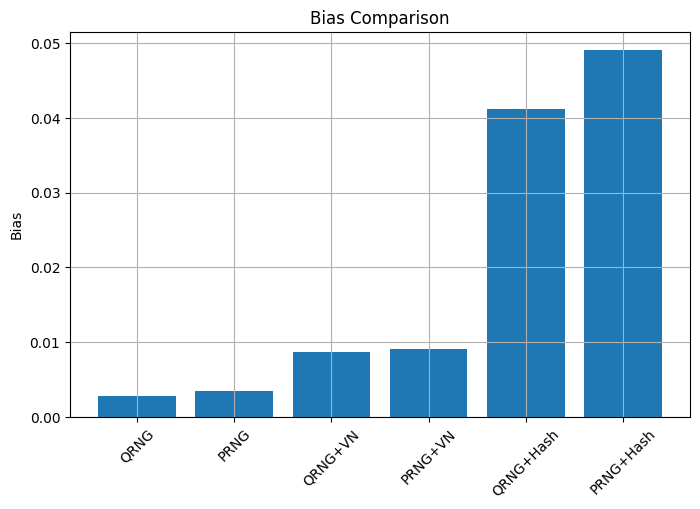

QRNG
Entropy: 0.9999773784235225
Bias: 0.0028000000000000247
----------------------
PRNG
Entropy: 0.9999646536828334
Bias: 0.003500000000000003
----------------------
QRNG+VN
Entropy: 0.9997799022273355
Bias: 0.008733624454148492
----------------------
PRNG+VN
Entropy: 0.9997580177333725
Bias: 0.00915750915750918
----------------------
QRNG+Hash
Entropy: 0.9951022712641691
Bias: 0.04117647058823526
----------------------
PRNG+Hash
Entropy: 0.9930554830121974
Bias: 0.0490196078431373
----------------------


In [ ]:
import numpy as np
import random
import hashlib
import math
import matplotlib.pyplot as plt
from collections import Counter

# ----------------------------
# QRNG from Qiskit (simplified)
# ----------------------------
def entropy_analysis(n):
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.h(1)
    qc.measure_all()

    sim = AerSimulator()
    compiled = transpile(qc, sim)

    result = sim.run(compiled, shots=n).result()
    counts = result.get_counts()

    total = sum(counts.values())

    bits = []
    for k, v in counts.items():
        bits.extend([k] * v)

    random.shuffle(bits)
    bits = ''.join(bits)

    return bits


# ----------------------------
# PRNG generator
# ----------------------------
def prng_bits(n):
    return ''.join([str(random.randint(0,1)) for _ in range(n)])


# ----------------------------
# Von Neumann Extractor
# ----------------------------
def von_neumann(bits):
    result = []
    for i in range(0, len(bits)-1, 2):
        pair = bits[i:i+2]
        if pair == "01":
            result.append("0")
        elif pair == "10":
            result.append("1")
    return ''.join(result)


# ----------------------------
# Hash Extractor (SHA-256)
# ----------------------------
def hash_extractor(bits):
    h = hashlib.sha256(bits.encode()).hexdigest()
    return bin(int(h, 16))[2:]


# ----------------------------
# Entropy
# ----------------------------
def entropy(bits):
    counts = Counter(bits)
    probs = [c/len(bits) for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs)


# ----------------------------
# Bias
# ----------------------------
def bias(bits):
    p1 = bits.count('1') / len(bits)
    return abs(p1 - 0.5)


# ----------------------------
# Autocorrelation (lag 1)
# ----------------------------
def autocorr(bits):
    data = np.array([int(b) for b in bits])
    return np.corrcoef(data[:-1], data[1:])[0,1]


# ----------------------------
# Generate Data
# ----------------------------
n = 10000

qrng = entropy_analysis(n)
prng = prng_bits(n)

qrng_vn = von_neumann(qrng)
prng_vn = von_neumann(prng)

qrng_hash = hash_extractor(qrng)
prng_hash = hash_extractor(prng)


# ----------------------------
# Metrics
# ----------------------------
methods = ["QRNG", "PRNG", "QRNG+VN", "PRNG+VN", "QRNG+Hash", "PRNG+Hash"]

entropy_vals = [
    entropy(qrng),
    entropy(prng),
    entropy(qrng_vn),
    entropy(prng_vn),
    entropy(qrng_hash),
    entropy(prng_hash)
]

bias_vals = [
    bias(qrng),
    bias(prng),
    bias(qrng_vn),
    bias(prng_vn),
    bias(qrng_hash),
    bias(prng_hash)
]


# ----------------------------
# Plot 1: Entropy Comparison
# ----------------------------
plt.figure(figsize=(8,5))
plt.bar(methods, entropy_vals)
plt.xticks(rotation=45)
plt.title("Entropy Comparison: QRNG vs PRNG + Corrections")
plt.ylabel("Entropy")
plt.grid()
plt.show()


# ----------------------------
# Plot 2: Bias Comparison
# ----------------------------
plt.figure(figsize=(8,5))
plt.bar(methods, bias_vals)
plt.xticks(rotation=45)
plt.title("Bias Comparison")
plt.ylabel("Bias")
plt.grid()
plt.show()


# ----------------------------
# Print Results
# ----------------------------
for i in range(len(methods)):
    print(methods[i])
    print("Entropy:", entropy_vals[i])
    print("Bias:", bias_vals[i])
    print("----------------------")